# Where the non-SNP GEA hits land — SV hits, and small indels for comparison

**What this is.** A description of the GEA's own hits: what kind of variant they are, and where
in the genome they sit, each set against **everything the GEA tested** (the right background:
only variants common enough to test can become hits).

**Hits.** The GEA's own call, as in `genes/convergence/build_gea_pool.py`: raw LFMM p-values
(gen 9, 22 climate axes = bio1–19 + pc1–3), per class × axis MAF > 0.05, Bonferroni at
0.05 / records tested; a record is a hit if it clears that bar on **any** axis in any of the
three class scans (SV, small indel, and the two pooled). Nothing is re-estimated here.

**Classes and types.** *SV* = the record is in the SV scan (≥ 50 bp); *small indel* otherwise.
*Deletion* = REF longer than ALT, *insertion* = ALT longer, both relative to Col-0 (not to the
ancestral state). Equal-length MNPs are neither and are set aside, counted in section 0.

**Regions.** The same classifier the candidate pool uses
(`genes/dissection/screen_sig_blocks.classify`), run on every tested record
(`annotate_gea_universe.py`). First match wins, gene body before promoter:
CDS > UTR / non-coding exon > intron > **promoter (≤ 1 kb upstream of a TSS, strand-aware, outside
any gene body)** > reference TE > intergenic (proximal) > gene desert.

**Unit.** One row per variant record, as the GEA tests it — so one SV can appear as several
records (arch3 splits it per assembly path); see `sv_purging_fixed.ipynb` for why the burden and
purging work collapses those into events. Split records at identical position and lengths are
collapsed here, keeping the record the GEA called (2,938 hits, as in the candidate pool).

**Enrichment.** For a region *R*: the odds that a variant in *R* is a hit, over the odds for a
variant outside *R*, Mantel–Haenszel over size-bin × MAF-bin strata (hits skew common and
towards particular sizes, so an unadjusted share would mislead), with 95% CIs from resampling
the GEA's LD blocks — hits cluster in blocks, so records are not independent.

In [1]:
import os, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
CONV = os.path.abspath("../genes/convergence"); sys.path.insert(0, CONV)
import plot_theme as TH
import gea_region_by_axis as GR          # or_with_ci (MH + block bootstrap), size / MAF bins
TH.apply()
PLOTS = os.path.abspath("plots/gea_hit_landscape"); os.makedirs(PLOTS, exist_ok=True)
pd.set_option("display.width", 200); pd.set_option("display.max_rows", 400)

K4 = ["chrom", "pos", "ref_len", "alt_len"]
U = pd.read_csv(f"{CONV}/results/gea_hit_landscape.csv.gz")
n_raw = len(U)
# split records -> one; prefer the record the GEA called (its min p can be the higher of the two:
# the call may come from the SV scan, the min p here is from the pooled scan)
U = U.sort_values(["hit", "min_p"], ascending=[False, True]).drop_duplicates(K4).reset_index(drop=True)
REGION = {"1_CDS": "CDS", "2_UTR": "UTR / ncRNA exon", "4_exon_noncoding": "UTR / ncRNA exon",
          "5_intron": "intron", "3_promoter": "promoter (≤1 kb)", "6_TE": "TE",
          "7_proximal_intergenic": "intergenic", "8_gene_desert": "gene desert"}
RORDER = ["CDS", "UTR / ncRNA exon", "intron", "promoter (≤1 kb)", "TE", "intergenic", "gene desert"]
U["region"] = U.tier_1kb.map(REGION)
U["stratum"] = (pd.cut(U["size"], GR.SIZE_BINS, labels=False).astype(str) + "|"
                + pd.cut(U.MAF, GR.MAF_BINS, labels=False, include_lowest=True).astype(str))
# SV colour convention of notebooks/sv_burden_final_models.ipynb: insertions forest green,
# deletions orange, and NO blue or red for variant classes -- those are the garden-temperature
# scale, used for direction in section 7. (sv_main_fig1.ipynb swaps green and orange; the
# final-models convention is the one followed here.)
KIND = {"deletion": "#F07A2E", "insertion": "#4E6B3A"}
REF = TH.MUTED                                           # "all tested" is context, drawn grey
rng = np.random.default_rng(1)
print(f"{n_raw:,} tested records -> {len(U):,} after collapsing split records; "
      f"{int(U.hit.sum()):,} GEA hits (the candidate pool has 2,938)")

703,789 tested records -> 682,577 after collapsing split records; 2,938 GEA hits (the candidate pool has 2,938)


## 0 · The numbers

Tested records and GEA hits by class and type; *per 10k* is the hit rate, *blocks* the number of
distinct LD blocks the hits fall in (hits cluster, so blocks are the conservative count).

In [2]:
T = U.groupby(["cls", "kind"]).agg(tested=("hit", "size"), hits=("hit", "sum"))
T["hits per 10k tested"] = (1e4 * T.hits / T.tested).round(1)
T["hit blocks"] = U[U.hit].groupby(["cls", "kind"]).block.nunique()
T["share of class hits"] = (T.hits / T.groupby(level=0).hits.transform("sum")).round(3)
print(T.fillna(0).astype({"hit blocks": int}).to_string())
sv = U[(U.cls == "sv") & U.kind.isin(["deletion", "insertion"])].copy()
si = U[(U.cls == "smallindel") & U.kind.isin(["deletion", "insertion"])].copy()
print(f"\nSV hits: {int(sv.hit.sum())} ({int(sv[sv.hit].kind.eq('deletion').sum())} deletions, "
      f"{int(sv[sv.hit].kind.eq('insertion').sum())} insertions) in {sv[sv.hit].block.nunique()} blocks")

                      tested  hits  hits per 10k tested  hit blocks  share of class hits
cls        kind                                                                         
smallindel deletion   270321  1050                 38.8         695                0.406
           insertion  243634  1003                 41.2         680                0.388
           mnp        144565   534                 36.9         276                0.206
sv         deletion    13422   170                126.7         141                0.484
           insertion   10635   181                170.2         158                0.516



SV hits: 351 (170 deletions, 181 insertions) in 281 blocks


## 1 · What the SV hits are — size and frequency

**A–B** size of SV deletions and insertions: GEA hits (bars) against every SV of that type the
GEA tested (grey line), each as a share of its own set so the shapes compare. **C** minor allele
frequency: hits by type against all tested SVs. The enrichment tests below stratify on
frequency and size anyway, so a difference in either cannot masquerade as a regional one.

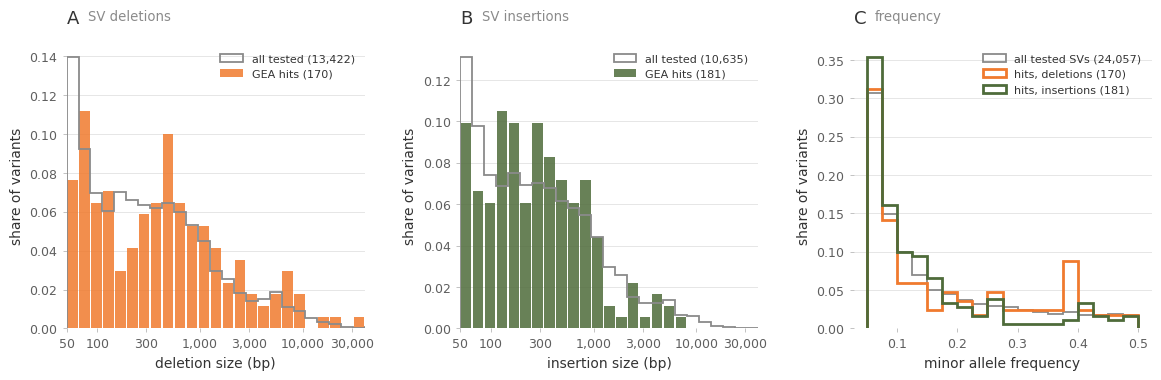

deletion  median size: hits 402 bp, tested 252 bp | median MAF: hits 0.119, tested 0.138
insertion median size: hits 270 bp, tested 236 bp | median MAF: hits 0.098, tested 0.087


In [3]:
fig, axs = plt.subplots(1, 3, figsize=(14, 3.7), gridspec_kw=dict(wspace=0.32))
bins = np.linspace(np.log10(50), np.log10(sv["size"].max()) + 0.01, 30)
tick = [50, 100, 300, 1000, 3000, 10000, 30000]
for ax, k, L in zip(axs[:2], ["deletion", "insertion"], "AB"):
    t = sv[sv.kind == k]; h = t[t.hit]
    ax.hist(np.log10(t["size"]), bins=bins, weights=np.full(len(t), 1 / len(t)), histtype="step",
            color=REF, lw=1.3, label=f"all tested ({len(t):,})")
    ax.hist(np.log10(h["size"]), bins=bins, weights=np.full(len(h), 1 / len(h)), color=KIND[k],
            alpha=0.85, rwidth=0.88, label=f"GEA hits ({len(h):,})")
    ax.set_xticks(np.log10(tick)); ax.set_xticklabels([f"{v:,}" for v in tick])
    ax.set_xlim(bins[0], min(bins[-1], np.log10(40000)))
    ax.set_xlabel(f"{k} size (bp)"); ax.set_ylabel("share of variants")
    TH.grid_only(ax, "y"); TH.panel(ax, L, f"SV {k}s", y=1.12); ax.legend(loc="upper right")
ax = axs[2]; mb = np.linspace(0.05, 0.5, 19)
ax.hist(sv.MAF, bins=mb, weights=np.full(len(sv), 1 / len(sv)), histtype="step", color=REF, lw=1.3,
        label=f"all tested SVs ({len(sv):,})")
for k in KIND:
    h = sv[sv.hit & (sv.kind == k)]
    ax.hist(h.MAF, bins=mb, weights=np.full(len(h), 1 / len(h)), histtype="step", color=KIND[k],
            lw=2, label=f"hits, {k}s ({len(h)})")
ax.set_xlabel("minor allele frequency"); ax.set_ylabel("share of variants")
TH.grid_only(ax, "y"); TH.panel(ax, "C", "frequency", y=1.12); ax.legend(loc="upper right")
plt.savefig(f"{PLOTS}/sv_hits_size_maf.png", dpi=170, bbox_inches="tight"); plt.show()
for k in KIND:
    t = sv[sv.kind == k]
    print(f"{k:9s} median size: hits {t[t.hit]['size'].median():,.0f} bp, tested {t['size'].median():,.0f} bp | "
          f"median MAF: hits {t[t.hit].MAF.median():.3f}, tested {t.MAF.median():.3f}")

## 2 · Where the SV hits land

**A–B** share of SV hits in each region (bars), deletions and insertions separately, with the
share among **all tested SVs of the same type** as a grey tick — a bar past its tick means that
region holds more of the hits than of the tested variants. *n* in each label is the hit count.
**C** the same comparison as an enrichment: Mantel–Haenszel odds ratio over size × MAF strata,
95% block-bootstrap CI, log scale; filled = CI excludes 1.

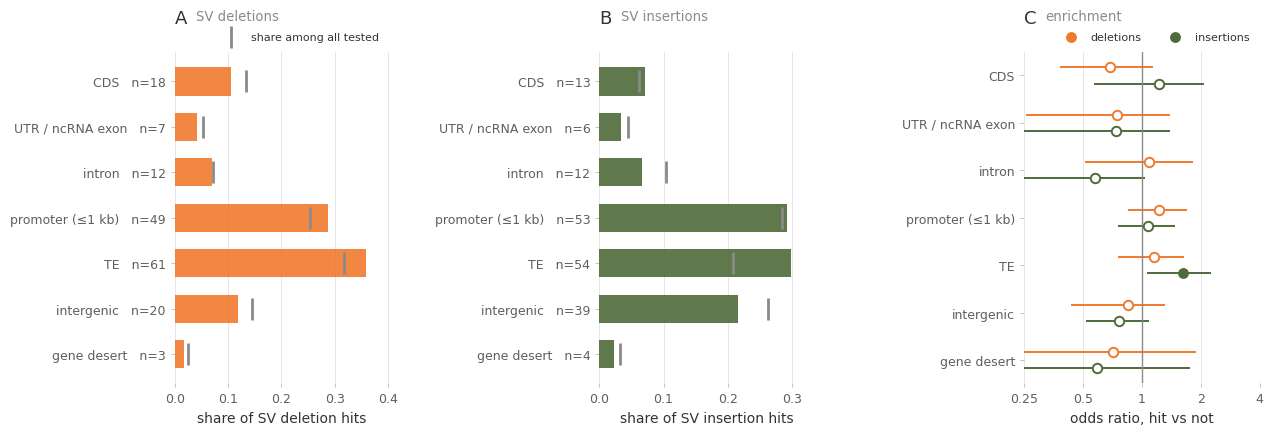

     kind           region  hits  tested  hit_share  tested_share   OR   lo   hi     p
 deletion              CDS    18    1783      0.106         0.133 0.68 0.38 1.14 0.156
 deletion UTR / ncRNA exon     7     708      0.041         0.053 0.75 0.25 1.38 0.364
 deletion           intron    12     964      0.071         0.072 1.09 0.51 1.83 0.810
 deletion promoter (≤1 kb)    49    3414      0.288         0.254 1.22 0.85 1.69 0.282
 deletion               TE    61    4266      0.359         0.318 1.16 0.75 1.64 0.470
 deletion       intergenic    20    1951      0.118         0.145 0.85 0.43 1.32 0.440
 deletion      gene desert     3     336      0.018         0.025 0.71 0.00 1.90 0.538
insertion              CDS    13     654      0.072         0.061 1.22 0.57 2.08 0.590
insertion UTR / ncRNA exon     6     481      0.033         0.045 0.74 0.24 1.39 0.370
insertion           intron    12    1109      0.066         0.104 0.58 0.25 1.03 0.062
insertion promoter (≤1 kb)    53    3027   

In [4]:
def region_stats(D):
    rows = []
    for k in KIND:
        d = D[D.kind == k]
        for r in RORDER:
            e = d.assign(_x=d.region.eq(r))
            if e._x.sum() == 0:
                continue
            o, lo, hi, p = GR.or_with_ci(e, "hit", "_x", rng)
            rows.append(dict(kind=k, region=r, hits=int((e.hit & e._x).sum()), tested=int(e._x.sum()),
                             hit_share=e[e.hit]._x.mean(), tested_share=e._x.mean(),
                             OR=o, lo=lo, hi=hi, p=p))
    return pd.DataFrame(rows)


XL = (0.25, 4.0)                      # odds-ratio axis; a CI past it is drawn to the edge


def region_figure(D, S, cls_label, fname):
    fig = plt.figure(figsize=(14, 4.3)); gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.1], wspace=0.95)
    y = np.arange(len(RORDER))
    for i, (k, L) in enumerate(zip(KIND, "AB")):
        ax = fig.add_subplot(gs[0, i]); s = S[S.kind == k].set_index("region").reindex(RORDER)
        ax.barh(y, s.hit_share, color=KIND[k], height=0.62, alpha=0.9)
        ax.scatter(s.tested_share, y, marker="|", s=260, color=REF, lw=2, zorder=3,
                   label="share among all tested")
        ax.set_yticks(y); ax.set_yticklabels([f"{r}   n={int(n) if n == n else 0}" for r, n in zip(RORDER, s.hits)])
        ax.invert_yaxis(); ax.set_xlabel(f"share of {cls_label} {k} hits")
        ax.set_xlim(0, 1.12 * np.nanmax([s.hit_share.max(), s.tested_share.max()]))
        TH.grid_only(ax, "x"); TH.panel(ax, L, f"{cls_label} {k}s", y=1.13)
        if i == 0:
            ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.0))
    ax = fig.add_subplot(gs[0, 2])
    for j, k in enumerate(KIND):
        s = S[S.kind == k].set_index("region").reindex(RORDER); off = -0.17 if j == 0 else 0.17
        ok = s.OR.notna() & (s.OR > 0)
        yy = y[ok.values] + off; ss = s[ok].copy()
        ss["lo"] = ss.lo.clip(lower=XL[0]); ss["hi"] = ss.hi.clip(upper=XL[1])   # CIs run to the edge
        sig = (ss.lo > 1) | (ss.hi < 1)
        ax.errorbar(ss.OR, yy, xerr=[ss.OR - ss.lo, ss.hi - ss.OR], fmt="none", ecolor=KIND[k], lw=1.4)
        ax.scatter(ss.OR[sig], yy[sig.values], color=KIND[k], s=46, zorder=3, label=f"{k}s")
        ax.scatter(ss.OR[~sig], yy[~sig.values], facecolor="white", edgecolor=KIND[k], s=46, lw=1.4, zorder=3)
    ax.axvline(1, color=TH.MUTED, lw=1)
    ax.set_xscale("log"); ax.set_xlim(*XL); ax.minorticks_off()
    ax.set_xticks([0.25, 0.5, 1, 2, 4]); ax.set_xticklabels(["0.25", "0.5", "1", "2", "4"])
    ax.set_yticks(y); ax.set_yticklabels(RORDER); ax.invert_yaxis()
    ax.set_xlabel("odds ratio, hit vs not")
    TH.grid_only(ax, "x"); TH.panel(ax, "C", "enrichment", y=1.13)
    ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.0), ncol=2)
    plt.savefig(f"{PLOTS}/{fname}", dpi=170, bbox_inches="tight"); plt.show()


S_sv = region_stats(sv)
region_figure(sv, S_sv, "SV", "sv_hits_by_region.png")
print(S_sv.assign(hit_share=S_sv.hit_share.round(3), tested_share=S_sv.tested_share.round(3),
                  OR=S_sv.OR.round(2), lo=S_sv.lo.round(2), hi=S_sv.hi.round(2), p=S_sv.p.round(3)).to_string(index=False))

## 2b · Why promoters are already common among the tested variants

The grey ticks in section 2 are the share among **tested** variants, not the genome's share —
and among tested SV deletions promoters are about a quarter, far above the ~16% of the genome's
bases they cover. Two checks on where that comes from.

**A — is the promoter call right?** Every variant the classifier calls promoter is checked against
an *independent* signed distance to the nearest TSS (a different gene loader): a promoter call
should sit 0–1 kb upstream of a TSS, and a non-genic variant *not* called promoter should not.

**B — what would chance give?** A variant is an interval, not a base: a 2 kb deletion dropped at
random overlaps a gene body — which the classifier ranks first — far more often than a single base,
so a per-base genome share is the wrong yardstick for SVs. The baseline here is random positions
with the **same size distribution** as the tested variants of each class × type, run through the
**same classifier** (`gea_region_baseline.py`). **Left:** tested share ÷ that random share, per
region. **Right:** the same among variants *outside* gene bodies only, which removes the gene-body
effect and asks whether promoters hold more than their share of the non-genic variants.
Uniform placement includes sequence where nothing can be called (centromeric repeats, gaps),
which mainly moves the TE comparison.

A  share of variants sitting 0-1 kb upstream of the nearest TSS (independent gene loader):
                           set      n  share_0_1kb_upstream
               called promoter 188711                 0.966
non-genic, not called promoter 267128                 0.000


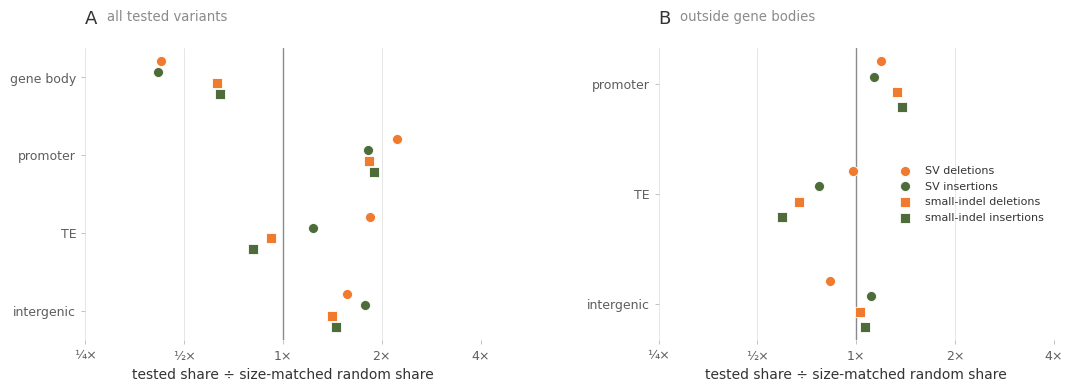

       cls      kind     region  random_share  tested_share  ratio  ratio_outside_genes
        sv  deletion  gene body         0.604         0.257  0.426                  NaN
        sv  deletion   promoter         0.114         0.254  2.226                1.189
        sv  deletion         TE         0.173         0.318  1.836                0.980
        sv  deletion intergenic         0.109         0.170  1.563                0.834
        sv insertion  gene body         0.508         0.211  0.416                  NaN
        sv insertion   promoter         0.157         0.285  1.812                1.130
        sv insertion         TE         0.169         0.209  1.234                0.770
        sv insertion intergenic         0.166         0.296  1.781                1.111
smallindel  deletion  gene body         0.503         0.318  0.631                  NaN
smallindel  deletion   promoter         0.157         0.287  1.832                1.334
smallindel  deletion         TE 

In [5]:
CA = pd.read_csv(f"{CONV}/results/gea_region_checkA.csv")
print("A  share of variants sitting 0-1 kb upstream of the nearest TSS (independent gene loader):")
print(CA.assign(share_0_1kb_upstream=CA.share_0_1kb_upstream.round(3)).to_string(index=False))
B = pd.read_csv(f"{CONV}/results/gea_region_baseline.csv")
SER = [("sv", "deletion"), ("sv", "insertion"), ("smallindel", "deletion"), ("smallindel", "insertion")]
MK = {"sv": "o", "smallindel": "s"}; LAB = {"sv": "SV", "smallindel": "small-indel"}
fig, axs = plt.subplots(1, 2, figsize=(12.5, 3.8), gridspec_kw=dict(wspace=0.45))
for ax, col, regs, L, txt in [(axs[0], "ratio", ["gene body", "promoter", "TE", "intergenic"], "A", "all tested variants"),
                              (axs[1], "ratio_outside_genes", ["promoter", "TE", "intergenic"], "B", "outside gene bodies")]:
    y = np.arange(len(regs))
    for j, (c, k) in enumerate(SER):
        d = B[(B.cls == c) & (B.kind == k)].set_index("region").reindex(regs)
        ax.scatter(np.log2(d[col]), y + (j - 1.5) * 0.14, marker=MK[c], s=52, color=KIND[k],
                   edgecolor="white", linewidth=0.6, zorder=3, label=f"{LAB[c]} {k}s")
    ax.axvline(0, color=TH.MUTED, lw=1)
    ax.set_yticks(y); ax.set_yticklabels(regs); ax.invert_yaxis()
    ax.set_xticks([-2, -1, 0, 1, 2]); ax.set_xticklabels(["¼×", "½×", "1×", "2×", "4×"]); ax.set_xlim(-2, 2)
    ax.set_xlabel("tested share ÷ size-matched random share")
    TH.grid_only(ax, "x"); TH.panel(ax, L, txt, y=1.13)
axs[1].legend(loc="center right")          # the 2x-4x band is empty in both panels
plt.savefig(f"{PLOTS}/tested_vs_size_matched_random.png", dpi=170, bbox_inches="tight"); plt.show()
print(B.assign(**{c: B[c].round(3) for c in ["random_share", "tested_share", "ratio", "ratio_outside_genes"]}).to_string(index=False))
gb = B[B.region == "gene body"]; po = B[B.region == "promoter"]
print(f"\ngene bodies hold {gb.ratio.min():.2f}-{gb.ratio.max():.2f}x their size-matched share; "
      f"outside genes, promoters hold {po.ratio_outside_genes.min():.2f}-{po.ratio_outside_genes.max():.2f}x theirs")

**Reading it.** The classifier's promoter calls check out (A). The large "promoter excess"
among tested variants is mostly a **gene-body deficit**: common indels and SVs are strongly
depleted from genes — purifying selection keeps variants in genes from reaching the 5% frequency
the GEA needs — so every region outside genes is inflated against the genome. Outside gene
bodies (B), promoters hold only modestly more than their share: a little for SVs, more for small
indels, where AT-rich poly-A/T runs typical of Arabidopsis promoters are a plausible mutational
source (not tested here). None of this enters the climate test in section 2, which compares hits
against these same tested variants and so holds all of it fixed.

## 3 · The same for small indels

Small indels are ~12× more numerous among the hits, so this is where the estimates are tight.
Same layout and the same statistic as section 2.

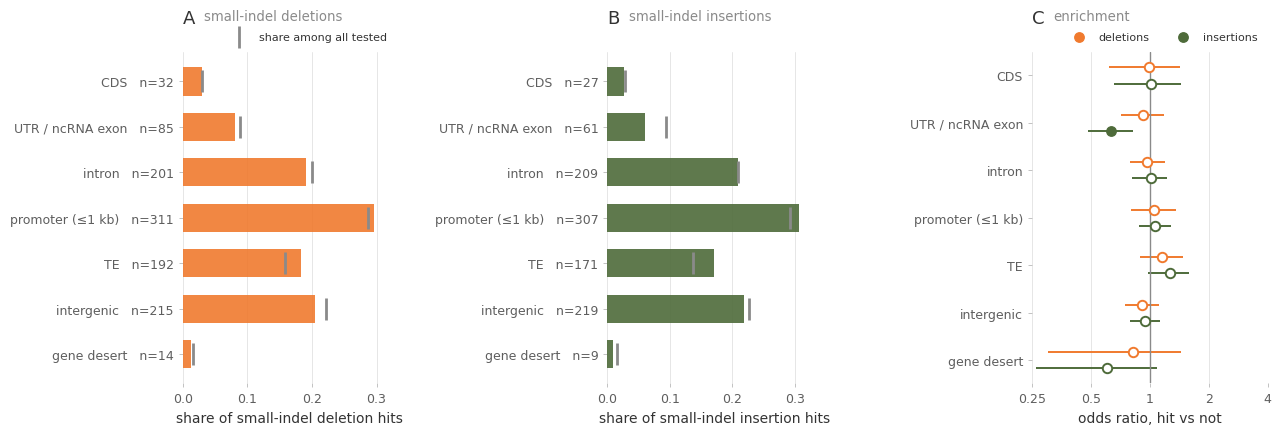

     kind           region  hits  tested  hit_share  tested_share   OR   lo   hi     p
 deletion              CDS    32    8066      0.030         0.030 0.99 0.62 1.42 0.938
 deletion UTR / ncRNA exon    85   23738      0.081         0.088 0.93 0.71 1.18 0.528
 deletion           intron   201   54086      0.191         0.200 0.96 0.79 1.20 0.694
 deletion promoter (≤1 kb)   311   77664      0.296         0.287 1.05 0.80 1.36 0.824
 deletion               TE   192   42641      0.183         0.158 1.16 0.89 1.48 0.280
 deletion       intergenic   215   59777      0.205         0.221 0.91 0.74 1.11 0.374
 deletion      gene desert    14    4349      0.013         0.016 0.82 0.30 1.43 0.462
insertion              CDS    27    6765      0.027         0.028 1.01 0.65 1.44 0.960
insertion UTR / ncRNA exon    61   22665      0.061         0.093 0.63 0.48 0.82 0.000
insertion           intron   209   50769      0.208         0.208 1.01 0.81 1.23 0.960
insertion promoter (≤1 kb)   307   71214   

In [6]:
S_si = region_stats(si)
region_figure(si, S_si, "small-indel", "smallindel_hits_by_region.png")
print(S_si.assign(hit_share=S_si.hit_share.round(3), tested_share=S_si.tested_share.round(3),
                  OR=S_si.OR.round(2), lo=S_si.lo.round(2), hi=S_si.hi.round(2), p=S_si.p.round(3)).to_string(index=False))
pd.concat([S_sv.assign(cls="sv"), S_si.assign(cls="smallindel")]).to_csv(
    f"{CONV}/results/gea_hits_region_enrichment.csv", index=False)

## 4 · Across the climate axes

For every axis with at least 20 hits (SVs and small indels together, deletions and insertions
together — split further, most cells are empty): each region's share of **that axis's** hits
divided by its share among all tested variants, on a log₂ scale. Green = more hits than the
region's size predicts, purple = fewer, grey = as expected. Cells where fewer than 3 hits are
expected are left blank: a ratio there is noise. The count after each axis name is its number
of hits. The axes are correlated with each other, so rows are not independent.

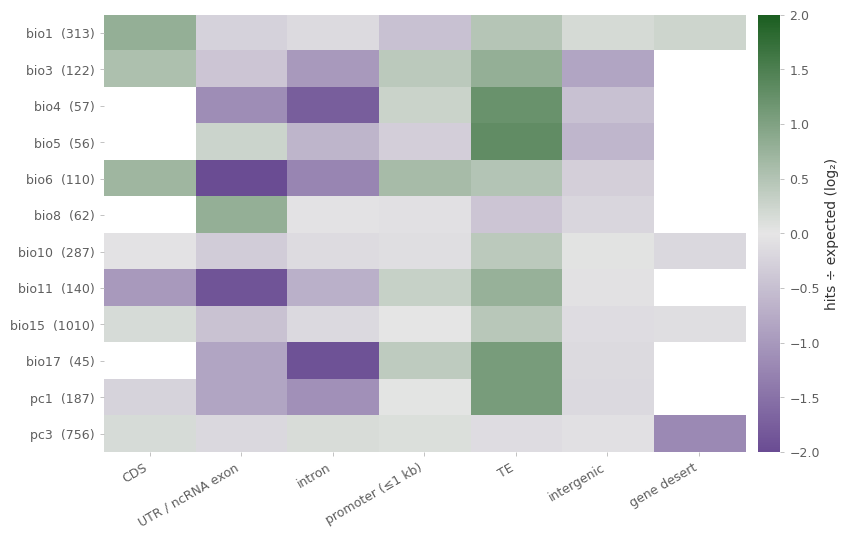

regions consistently above expectation (log2 > 0 on most axes):
CDS                 0.42
UTR / ncRNA exon    0.17
intron              0.08
promoter (≤1 kb)    0.67
TE                  0.83
intergenic          0.17
gene desert         0.08


In [7]:
A = U[U.kind.isin(["deletion", "insertion"])]
exp_share = A.region.value_counts(normalize=True).reindex(RORDER)
rows, counts = [], {}
for ax_ in GR.AXES:
    h = A[A.hit_axes.fillna("").str.split(",").map(lambda s: ax_ in s)]
    if len(h) < 20:
        continue
    counts[ax_] = len(h)
    obs = h.region.value_counts().reindex(RORDER).fillna(0); exp = exp_share * len(h)
    rows.append(np.where(exp >= 3, np.log2((obs + 0.5) / (exp + 0.5)), np.nan))
M = np.array(rows); names = list(counts)
cmap = LinearSegmentedColormap.from_list("enr", ["#6A4C93", "#E6E6E6", "#1B5E20"])
fig, ax = plt.subplots(figsize=(8.8, 0.34 * len(names) + 1.6))
im = ax.imshow(M, cmap=cmap, vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(RORDER))); ax.set_xticklabels(RORDER, rotation=30, ha="right")
ax.set_yticks(range(len(names))); ax.set_yticklabels([f"{a}  ({counts[a]})" for a in names])
ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02); cb.set_label("hits ÷ expected (log₂)", color=TH.LABEL)
cb.outline.set_visible(False)
plt.savefig(f"{PLOTS}/hits_by_region_by_axis.png", dpi=170, bbox_inches="tight"); plt.show()
print("regions consistently above expectation (log2 > 0 on most axes):")
print(pd.Series((M > 0).mean(0), index=RORDER).round(2).to_string())

## 5 · Distance to the nearest transcription start site

Signed distance from each variant to the nearest TSS, in the gene's orientation (negative =
upstream). Only the ±3 kb window is drawn, but each bar is a share of the set's **total**, so the
curves also show how much of each set lies near a TSS at all (variants farther away are in no
bar). SV hits by type against all tested SVs.

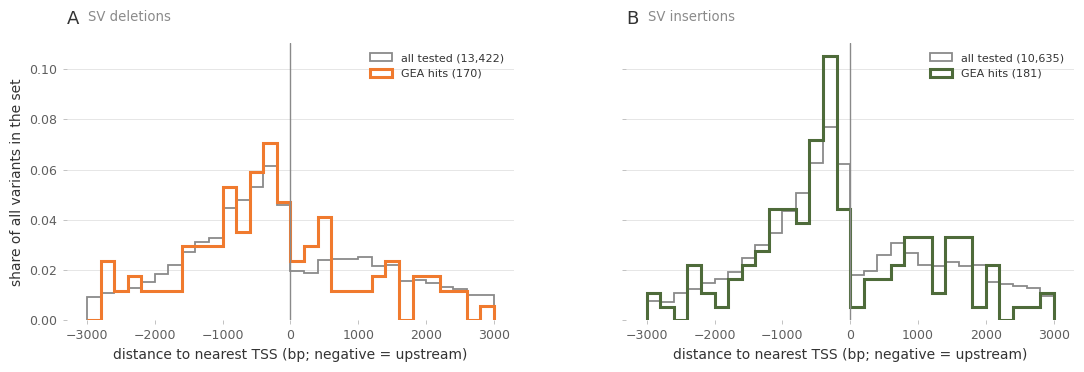

deletion  within 1 kb of a TSS: hits 0.382, tested 0.364
insertion within 1 kb of a TSS: hits 0.398, tested 0.417


In [8]:
fig, axs = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw=dict(wspace=0.25), sharey=True)
b = np.arange(-3000, 3001, 200)
for ax, k, L in zip(axs, ["deletion", "insertion"], "AB"):
    t = sv[sv.kind == k]; h = t[t.hit]
    tw, hw = t[t.dist_tss.abs() <= 3000], h[h.dist_tss.abs() <= 3000]
    ax.hist(tw.dist_tss, bins=b, weights=np.full(len(tw), 1 / len(t)), histtype="step",
            color=REF, lw=1.3, label=f"all tested ({len(t):,})")
    ax.hist(hw.dist_tss, bins=b, weights=np.full(len(hw), 1 / len(h)), histtype="step",
            color=KIND[k], lw=2.2, label=f"GEA hits ({len(h)})")
    ax.axvline(0, color=TH.MUTED, lw=1)
    ax.set_xlabel("distance to nearest TSS (bp; negative = upstream)")
    TH.grid_only(ax, "y"); TH.panel(ax, L, f"SV {k}s", y=1.12); ax.legend(loc="upper right")
axs[0].set_ylabel("share of all variants in the set")
plt.savefig(f"{PLOTS}/sv_hits_tss_distance.png", dpi=170, bbox_inches="tight"); plt.show()
for k in KIND:
    t = sv[sv.kind == k]; near = lambda d: (d.dist_tss.abs() <= 1000).mean()
    print(f"{k:9s} within 1 kb of a TSS: hits {near(t[t.hit]):.3f}, tested {near(t):.3f}")

## 6 · The SV hits, by region

Every SV hit with its region and the gene the region call is about (`gene` from the candidate
pool's classification — for a promoter, the gene whose promoter it is; for intergenic / TE /
gene desert, no host gene). Sorted by region, then by p. Also written to
`genes/convergence/results/gea_sv_hits_by_region.csv`.

In [9]:
V = pd.read_csv(f"{CONV}/results/variants_classified.csv", low_memory=False, usecols=K4 + ["gene", "nearest_gene"])
H = sv[sv.hit].merge(V.drop_duplicates(K4), on=K4, how="left")
H["host_gene"] = np.where(H.region.isin(["CDS", "UTR / ncRNA exon", "intron", "promoter (≤1 kb)"]), H.gene, "")
H["region"] = pd.Categorical(H.region, RORDER, ordered=True)
H = H.sort_values(["region", "min_p"])
cols = ["region", "kind", "size", "chrom", "pos", "host_gene", "nearest_gene", "MAF", "n_hit_axes", "hit_axes", "min_p"]
H[cols].to_csv(f"{CONV}/results/gea_sv_hits_by_region.csv", index=False)
print(H.groupby(["region", "kind"], observed=True).size().unstack(fill_value=0).to_string())
H[cols].assign(MAF=H.MAF.round(3), min_p=H.min_p.map(lambda v: f"{v:.1e}")).reset_index(drop=True)

kind              deletion  insertion
region                               
CDS                     18         13
UTR / ncRNA exon         7          6
intron                  12         12
promoter (≤1 kb)        49         53
TE                      61         54
intergenic              20         39
gene desert              3          4


,region,kind,size,chrom,pos,host_gene,nearest_gene,MAF,n_hit_axes,hit_axes,min_p
0,CDS,deletion,450,Chr3,7805120,AT3G22142,AT3G22142,0.066,2,"bio1,bio15",6.2e-12
1,CDS,insertion,312,Chr4,7204359,AT4G12020,AT4G12020,0.076,5,"bio1,bio3,bio6,bio11,pc1",1.3e-09
2,CDS,insertion,4566,Chr4,7319259,AT4G12330,AT4G12330,0.055,3,"bio1,bio10,pc3",2.7e-08
3,CDS,deletion,2353,Chr2,15326395,AT2G36540,AT2G36540,0.085,1,bio15,6.6e-08
4,CDS,insertion,4402,Chr2,5681837,AT2G13623,AT2G13623,0.052,1,pc3,8.1e-08
5,CDS,deletion,2779,Chr2,11523547,AT2G27000,AT2G27000,0.290,1,bio3,1.0e-07
6,CDS,deletion,2234,Chr4,963452,AT4G02180,AT4G02180,0.057,3,"bio4,bio6,bio7",1.5e-07
7,CDS,deletion,4710,Chr4,6589103,AT4G10695,AT4G10695,0.152,1,pc3,1.6e-07
8,CDS,deletion,904,Chr2,7923833,AT2G18200,AT2G18200,0.148,1,bio1,1.9e-07
9,CDS,deletion,599,Chr3,11965676,AT3G30370,AT3G30370,0.096,1,bio15,1.9e-07


## 7 · Warm or cold? The direction of the GEA hits

**The sign.** The GEA's saved output is p-values only. `genes/convergence/lfmm_signed/` re-ran the
**identical** model (same Δp input, LFMM ridge K = 16, raw p) on every axis and kept the effect size
and z-score that the original run computed and discarded; all 22 axes reproduced the saved p-values
exactly (largest |Δlog₁₀ p| = 1.8 × 10⁻¹⁵). So this is the GEA's own direction, recovered — not a new
statistic.

**What "warm" means.** The input is the change in frequency of the ALT allele and the climate axis is
z-scored, so z > 0 means the ALT allele rose more where the axis is higher. For a deletion the ALT
allele *is* the deletion. Nine axes measure temperature: bio1, bio5, bio6, bio8, bio9, bio10, bio11,
and pc1 and pc3, which point towards higher bio1 and bio10. On all of them z > 0 = favoured **warm**.

**One sign per variant.** The temperature axes are strongly correlated, so a variant is not counted
once per axis: it takes its sign on the temperature axis where it is **most** significant
(`gea_direction_by_record.py`). *Temperature hits* are GEA hits on at least one temperature axis.

**The figures.** One per variant class — SVs first, then small indels — each with deletions and
insertions side by side. Every bar is a **count of hits**, drawn in the direction of its effect:
left (blue) = hits whose allele rises in COLDER gardens (z < 0), right (red) = hits whose allele
rises in WARMER gardens (z > 0). For a deletion the allele is the deletion itself, so a red bar
means "this deletion is favoured in the warm". The row label gives the total and the warm share;
p (binomial, against that region and type's warm share among all tested variants, which sits at
~50%) is in the table below.

temperature hits: 1,381 (230 SV, 1151 small indel); leaning warm 0.625  (all tested: 0.499)


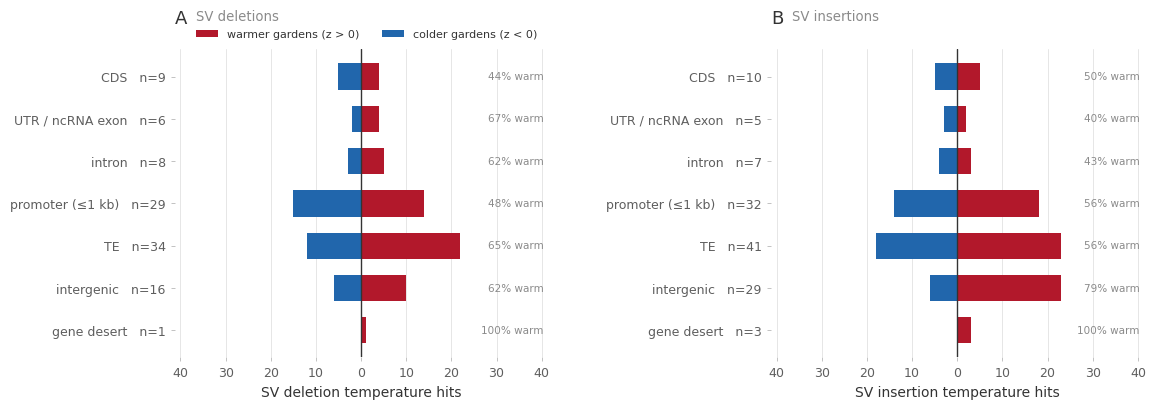

In [10]:
from scipy.stats import binomtest
DR = pd.read_csv(f"{CONV}/results/gea_direction_by_record.csv.gz")
DR["region"] = DR.tier_1kb.map(REGION)
COLD, WARM = "#2166AC", "#B2182B"          # direction is a polarity: the theme's cold/warm pair
CLSLAB = {"sv": "SV", "smallindel": "small-indel"}
rows = []
for cls in ("sv", "smallindel"):
    for k in KIND:
        d = DR[(DR.cls == cls) & (DR.kind == k)]
        for r in RORDER:
            x = d[d.region == r]; h = x[x.temp_hit]
            warm = int(h.warm.sum()); cold = len(h) - warm
            base = x.warm.mean()
            rows.append(dict(cls=cls, kind=k, region=r, hits=len(h), warm=warm, cold=cold,
                             warm_share=warm / len(h) if len(h) else np.nan, tested_warm_share=base,
                             p_vs_tested=binomtest(warm, len(h), base).pvalue if len(h) else np.nan))
W = pd.DataFrame(rows)

def direction_figure(cls):
    fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.0), gridspec_kw=dict(wspace=0.6))
    y = np.arange(len(RORDER))
    lim = W[W.cls == cls][["warm", "cold"]].max().max() * 1.75 + 1   # headroom for the % labels
    for ax, k, L in zip(axs, KIND, "AB"):
        w = W[(W.cls == cls) & (W.kind == k)].set_index("region").reindex(RORDER)
        ax.barh(y, w.warm, color=WARM, height=0.62, label="warmer gardens (z > 0)")
        ax.barh(y, -w.cold, color=COLD, height=0.62, label="colder gardens (z < 0)")
        ax.axvline(0, color=TH.LABEL, lw=1)
        for i, (n, ws) in enumerate(zip(w.hits, w.warm_share)):
            if n:
                ax.annotate(f"{ws:.0%} warm", xy=(lim * 0.98, i), ha="right", va="center",
                            fontsize=7.5, color=TH.MUTED)
        ax.set_yticks(y); ax.set_yticklabels([f"{r}   n={int(n)}" for r, n in zip(RORDER, w.hits)])
        ax.invert_yaxis(); ax.set_xlim(-lim, lim)
        t = np.array([t for t in ax.get_xticks() if abs(t) <= lim])
        ax.set_xticks(t); ax.set_xticklabels([f"{abs(int(v))}" for v in t])
        ax.set_xlabel(f"{CLSLAB[cls]} {k} temperature hits")
        TH.grid_only(ax, "x"); TH.panel(ax, L, f"{CLSLAB[cls]} {k}s", y=1.13)
    axs[0].legend(loc="lower right", bbox_to_anchor=(1.0, 1.0), ncol=2)
    plt.savefig(f"{PLOTS}/temperature_hits_direction_{cls}.png", dpi=170, bbox_inches="tight"); plt.show()

th = DR[DR.temp_hit]
print(f"temperature hits: {len(th):,} ({int((th.cls == 'sv').sum())} SV, {int((th.cls == 'smallindel').sum())} small indel); "
      f"leaning warm {th.warm.mean():.3f}  (all tested: {DR.warm.mean():.3f})")
direction_figure("sv")

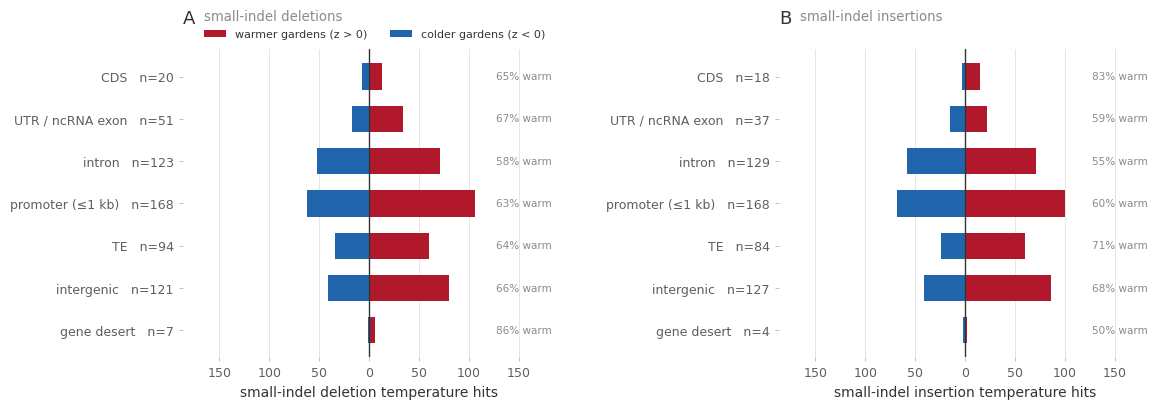

       cls      kind           region  hits  warm  cold  warm_share  tested_warm_share  p_vs_tested
        sv  deletion              CDS     9     4     5       0.444              0.486        1.000
        sv  deletion UTR / ncRNA exon     6     4     2       0.667              0.507        0.688
        sv  deletion           intron     8     5     3       0.625              0.492        0.501
        sv  deletion promoter (≤1 kb)    29    14    15       0.483              0.488        1.000
        sv  deletion               TE    34    22    12       0.647              0.498        0.088
        sv  deletion       intergenic    16    10     6       0.625              0.494        0.327
        sv  deletion      gene desert     1     1     0       1.000              0.554        1.000
        sv insertion              CDS    10     5     5       0.500              0.494        1.000
        sv insertion UTR / ncRNA exon     5     2     3       0.400              0.486        1.000


In [11]:
direction_figure("smallindel")
print(W.assign(**{c: W[c].round(3) for c in ["warm_share", "tested_warm_share", "p_vs_tested"]}).to_string(index=False))

**Promoter against intergenic deletions, axis by axis.** The comparison that matters is not
"do hits lean warm" — the table above shows most regions do — but whether **promoter** deletions lean
warmer than **intergenic** ones, the contrast of the burden model. Both are deletions relative to
Col-0, so anything that makes non-reference alleles as a class rise in warm gardens cancels out.
Below: the mean z of promoter deletions minus that of intergenic deletions, over **every tested**
deletion (the whole signed distribution, which is where a small shared shift would show), stratified
by size × MAF, 95% CI from resampling LD blocks (`gea_direction.py`). Above 0 = promoter deletions
lean warmer. Circles: SV deletions; squares: all deletions (small indels dominate).

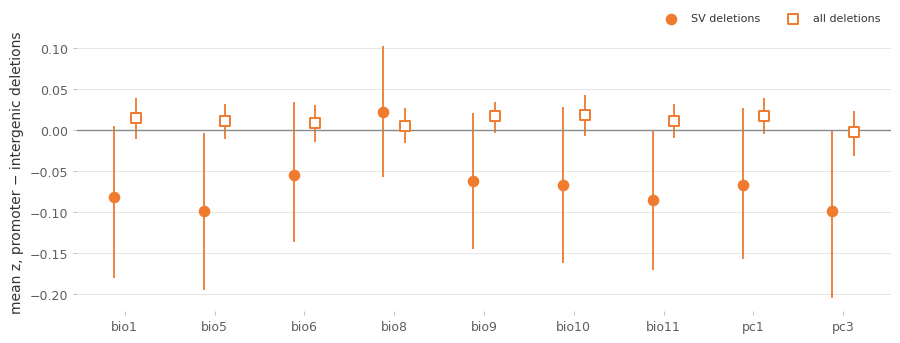

 axis cls  hits_promoter  warm_share_hits_promoter  hits_intergenic  warm_share_hits_intergenic  dz_promoter_minus_intergenic  dz_lo  dz_hi  dz_p
 bio1  sv              6                     0.333                5                       0.800                        -0.082 -0.181  0.005 0.078
 bio1 all             31                     0.710               41                       0.854                         0.015 -0.011  0.039 0.250
 bio5  sv              1                     0.000                2                       1.000                        -0.098 -0.195 -0.004 0.040
 bio5 all              8                     0.375                4                       0.500                         0.011 -0.011  0.032 0.352
 bio6  sv              5                     0.400                3                       0.667                        -0.054 -0.137  0.034 0.178
 bio6 all             21                     0.095                9                       0.556                         0.00

In [12]:
GDIR = pd.read_csv(f"{CONV}/results/gea_direction.csv")
TEMPAX = ["bio1", "bio5", "bio6", "bio8", "bio9", "bio10", "bio11", "pc1", "pc3"]
fig, ax = plt.subplots(figsize=(10.5, 3.6)); x = np.arange(len(TEMPAX))
for j, (cls, mk, lab) in enumerate([("sv", "o", "SV deletions"), ("all", "s", "all deletions")]):
    g = GDIR[(GDIR.cls == cls) & (GDIR.kind == "deletion")].set_index("axis").reindex(TEMPAX)
    xx = x + (-0.12 if j == 0 else 0.12)
    ax.errorbar(xx, g.dz_promoter_minus_intergenic, yerr=[g.dz_promoter_minus_intergenic - g.dz_lo, g.dz_hi - g.dz_promoter_minus_intergenic],
                fmt="none", ecolor=KIND["deletion"], lw=1.3)
    ax.scatter(xx, g.dz_promoter_minus_intergenic, marker=mk, s=48, color=KIND["deletion"] if j == 0 else "white",
               edgecolor=KIND["deletion"], lw=1.4, zorder=3, label=lab)
ax.axhline(0, color=TH.MUTED, lw=1)
ax.set_xticks(x); ax.set_xticklabels(TEMPAX); ax.set_ylabel("mean z, promoter − intergenic deletions")
TH.grid_only(ax, "y"); ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.0), ncol=2)
plt.savefig(f"{PLOTS}/promoter_vs_intergenic_direction.png", dpi=170, bbox_inches="tight"); plt.show()
c = ["axis", "cls", "hits_promoter", "warm_share_hits_promoter", "hits_intergenic", "warm_share_hits_intergenic",
     "dz_promoter_minus_intergenic", "dz_lo", "dz_hi", "dz_p"]
print(GDIR[(GDIR.kind == "deletion") & GDIR.axis.isin(TEMPAX) & GDIR.cls.isin(["sv", "all"])][c].round(3).to_string(index=False))

**Reading it.** Across all tested variants the sign is balanced (half lean warm), and the GEA's
temperature hits skew warm — 62.5% of them, 1,381 hits in all. The skew belongs to the **small
indels**, where every region leans warm (57–86%) and several clear a binomial test against their own
tested baseline: promoter deletions 63% (p = 0.001), intergenic deletions 66% (p < 0.001), TE
deletions 64% (p = 0.007), UTR deletions 67% (p = 0.017). The **SV** hits are far fewer (230) and
much noisier: SV promoter deletions sit at 48% warm — no skew at all — and the only SV cell that
clears the test is intergenic insertions (79%, p = 0.001). So the warm lean is a property of the
GEA's temperature hits at large, not of promoters, and it is carried by the small indels. On the
contrast that is specific: **promoter SV deletions do not lean
warmer than intergenic SV deletions** — if anything slightly colder, on eight of the nine
temperature axes, borderline on bio1, bio5, bio11 and pc3 (p = 0.04–0.08), nothing that survives
looking at nine correlated axes. Pooling in the small indels gives a small positive shift on eight
of nine axes, none significant. So,
taking the GEA's variants as they are, it does not reproduce the burden model's warm-favoured
promoter deletions. The next section shows why.

## 8 · The burden model's variant set

The burden model counts SVs as **events** (the alleles of a pangenome bubble collapsed with
`truvari collapse`), uses its own context — CDS > UTR > intron > reference TE > promoter (≤ 2 kb) >
intergenic — and keeps only **shared** variants (carried by both cold- and warm-origin founders),
called in ≥ 90% of founders with ≥ 2 carriers. Those labels exist per event in
`sv_event_catalog.csv`, so this section uses the event-level GEA of section 9 — the same LFMM, with
SVs counted as events — and applies the burden's labels to it unchanged
(`event_gea/event_direction_burden_defs.py`). Same contrast and CI as section 7; open = all tested
SV deletion events, filled = the burden's set.

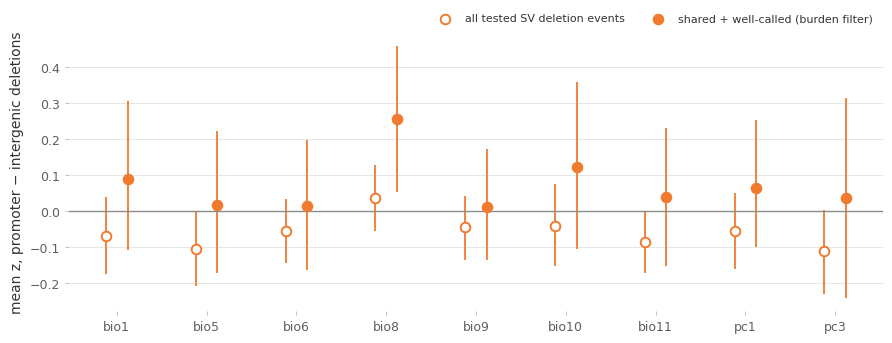

 axis      kind                             set  n_promoter  n_intergenic     dz     lo    hi     p
 bio1  deletion                      all tested        2384          1665 -0.068 -0.174 0.039 0.230
 bio1  deletion shared + passes (burden filter)         678           318  0.089 -0.108 0.304 0.386
 bio1 insertion                      all tested        4415          2722  0.009 -0.077 0.091 0.816
 bio1 insertion shared + passes (burden filter)        1739           755 -0.024 -0.166 0.121 0.740
 bio5  deletion                      all tested        2384          1665 -0.105 -0.206 0.001 0.052
 bio5  deletion shared + passes (burden filter)         678           318  0.017 -0.173 0.223 0.812
 bio5 insertion                      all tested        4415          2722  0.027 -0.052 0.103 0.484
 bio5 insertion shared + passes (burden filter)        1739           755 -0.030 -0.159 0.105 0.660
 bio6  deletion                      all tested        2384          1665 -0.055 -0.145 0.033 0.276


In [13]:
BD = pd.read_csv(f"{CONV}/event_gea/event_direction_burden_defs.csv")
fig, ax = plt.subplots(figsize=(10.5, 3.6)); x = np.arange(len(TEMPAX))
for j, (setname, lab, fill) in enumerate([("all tested", "all tested SV deletion events", False),
                                          ("shared + passes (burden filter)", "shared + well-called (burden filter)", True)]):
    g = BD[(BD.kind == "deletion") & (BD.set == setname)].set_index("axis").reindex(TEMPAX)
    xx = x + (-0.12 if j == 0 else 0.12)
    ax.errorbar(xx, g.dz, yerr=[g.dz - g.lo, g.hi - g.dz], fmt="none", ecolor=KIND["deletion"], lw=1.3)
    ax.scatter(xx, g.dz, s=48, color=KIND["deletion"] if fill else "white", edgecolor=KIND["deletion"], lw=1.4, zorder=3, label=lab)
ax.axhline(0, color=TH.MUTED, lw=1)
ax.set_xticks(x); ax.set_xticklabels(TEMPAX); ax.set_ylabel("mean z, promoter − intergenic deletions")
TH.grid_only(ax, "y"); ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.0), ncol=2)
plt.savefig(f"{PLOTS}/promoter_direction_burden_filter.png", dpi=170, bbox_inches="tight"); plt.show()
print(BD.round(3).to_string(index=False))

**Reading it.** Restricted to the burden's variant set, **the sign flips**: shared, well-called
promoter deletion events lean warmer than intergenic ones on **all nine** temperature axes — the burden
model's direction. It is individually significant only on bio8 (p = 0.018), with 678 promoter and 318
intergenic events, so the per-variant GEA cannot confirm the shift on its own; a small shift spread over
many variants is what a burden test, which sums over all of them, is built to see. Insertions show
nothing either way. What the filter removes is the variants carried only by cold- or only by
warm-origin founders, whose frequencies follow the fate of their lineage; among all tested SVs those
pull the promoter contrast towards cold.

## 9 · Parallel check: the GEA with SVs counted as events

*A parallel branch, kept out of the candidate tables (`genes/convergence/event_gea/`).*

The GEA tests every arch3 **record**, and arch3 writes one SV as one record per assembly path — the same
insertion or deletion recurs as several "alleles" differing by a base or two. Its frequency is split
across them: an SV whose alleles are each rare is never tested, and one that does reach MAF 0.05 can be
tested several times. Here the same LFMM (ridge K = 16, raw p, MAF ≥ 0.05, the same Δp input and climate
scaling) is run with each SV collapsed to its truvari event — frequency = the sum of its alleles'. Short
indels are unchanged: 676,203 units, identical to the GEA's small-indel records, whose Δp reproduces the
GEA's own input to within 3 × 10⁻⁸. Two scans as the GEA ran them (pooled non-SNP, SV-only), Bonferroni
per scan × axis.

SV events tested: 27,009 (the record-level GEA tests 27,586 SV records, touching 21,805 events)
  newly testable (no single allele reaches MAF 0.05; together they do): 5,345
SV event hits: 355  (164 deletions, 191 insertions)
  from newly testable events: 88  (hit rate 1.65% vs 1.23% among previously testable events)
  events carrying a record-level SV hit: 344; still a hit as an event: 171


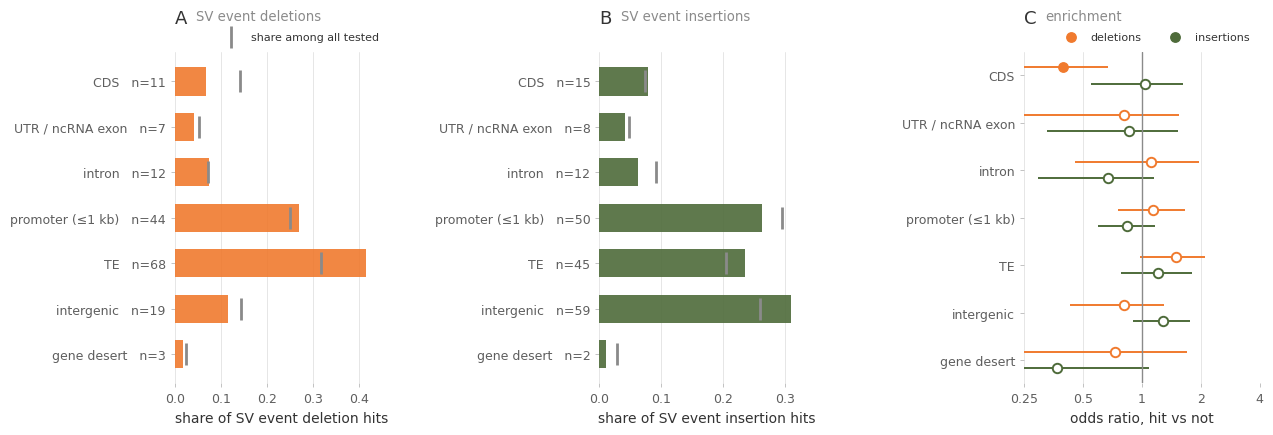

     kind           region  hits  tested  hit_share  tested_share    OR    lo    hi     p
 deletion              CDS    11    1866      0.067         0.141 0.396 0.191 0.672 0.000
 deletion UTR / ncRNA exon     7     694      0.043         0.052 0.810 0.238 1.548 0.562
 deletion           intron    12     946      0.073         0.071 1.110 0.454 1.965 0.818
 deletion promoter (≤1 kb)    44    3309      0.268         0.250 1.134 0.758 1.655 0.590
 deletion               TE    68    4195      0.415         0.316 1.494 0.982 2.095 0.062
 deletion       intergenic    19    1915      0.116         0.144 0.806 0.431 1.294 0.430
 deletion      gene desert     3     330      0.018         0.025 0.726 0.000 1.697 0.514
insertion              CDS    15    1023      0.079         0.074 1.034 0.550 1.626 0.900
insertion UTR / ncRNA exon     8     666      0.042         0.048 0.860 0.328 1.524 0.616
insertion           intron    12    1258      0.063         0.091 0.672 0.295 1.148 0.190
insertion 

In [14]:
EV = pd.read_csv(f"{CONV}/event_gea/event_sv_hits.csv")
EV["region"] = EV.tier.map(REGION)
EV["stratum"] = (pd.cut(EV["size"], GR.SIZE_BINS, labels=False).astype(str) + "|"
                 + pd.cut(EV.MAF, GR.MAF_BINS, labels=False, include_lowest=True).astype(str))
new = ~EV.allele_tested
print(f"SV events tested: {len(EV):,} (the record-level GEA tests 27,586 SV records, touching 21,805 events)")
print(f"  newly testable (no single allele reaches MAF 0.05; together they do): {int(new.sum()):,}")
print(f"SV event hits: {int(EV.hit.sum())}  ({int((EV.hit & (EV.kind == 'deletion')).sum())} deletions, "
      f"{int((EV.hit & (EV.kind == 'insertion')).sum())} insertions)")
print(f"  from newly testable events: {int((EV.hit & new).sum())}  (hit rate {100 * (EV.hit & new).sum() / new.sum():.2f}% "
      f"vs {100 * (EV.hit & ~new).sum() / (~new).sum():.2f}% among previously testable events)")
print(f"  events carrying a record-level SV hit: {int(EV.allele_hit.sum())}; still a hit as an event: {int((EV.hit & EV.allele_hit).sum())}")
S_ev = region_stats(EV)
region_figure(EV, S_ev, "SV event", "sv_event_hits_by_region.png")
print(S_ev.assign(**{c: S_ev[c].round(3) for c in ["hit_share", "tested_share", "OR", "lo", "hi", "p"]}).to_string(index=False))

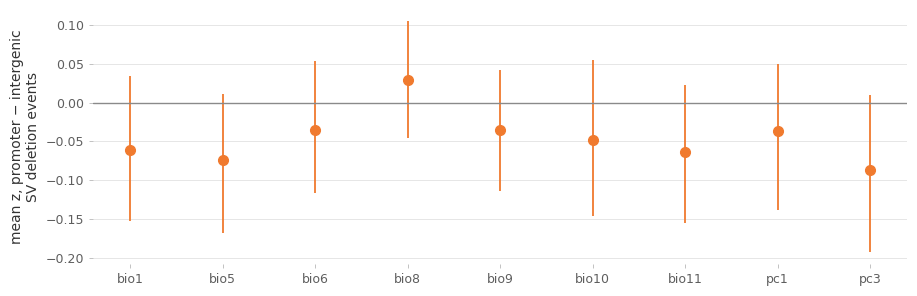

 axis  temperature  del_events  del_hits  hits_promoter  warm_hits_promoter  hits_intergenic  warm_hits_intergenic     dz  dz_lo  dz_hi  dz_p
 bio1         True       13255        22              5               0.400                3                 1.000 -0.061 -0.153  0.035 0.248
 bio5         True       13255         4              1               0.000                1                 1.000 -0.074 -0.169  0.011 0.104
 bio6         True       13255        11              4               0.500                1                 0.000 -0.036 -0.117  0.053 0.422
 bio8         True       13255         5              1               1.000                3                 0.000  0.029 -0.045  0.105 0.486
 bio9         True       13255         1              0                 NaN                0                   NaN -0.036 -0.114  0.042 0.372
bio10         True       13255        20              5               0.200                2                 1.000 -0.048 -0.147  0.055 0.320
bio11 

In [15]:
ED = pd.read_csv(f"{CONV}/event_gea/event_direction.csv")
g = ED.set_index("axis").reindex(TEMPAX)
fig, ax = plt.subplots(figsize=(10.5, 3.3)); x = np.arange(len(TEMPAX))
ax.errorbar(x, g.dz, yerr=[g.dz - g.dz_lo, g.dz_hi - g.dz], fmt="o", ms=7, color=KIND["deletion"], lw=1.3)
ax.axhline(0, color=TH.MUTED, lw=1)
ax.set_xticks(x); ax.set_xticklabels(TEMPAX); ax.set_ylabel("mean z, promoter − intergenic\nSV deletion events")
TH.grid_only(ax, "y")
plt.savefig(f"{PLOTS}/event_promoter_direction.png", dpi=170, bbox_inches="tight"); plt.show()
print(ED[ED.temperature].round(3).to_string(index=False))

**Reading it.** Counting SVs as events recovers **5,345 SV events** the record-level GEA never
tested, and they are not noise: 88 of them are hits, a hit rate (1.65%) a little above that of events
the GEA could already test (1.23%). The unit also **reshuffles which SVs are hits**: of the 344 events
that carry a record-level SV hit, only 171 are still hits when their alleles are summed, and 184 event
hits are new. Where the event hits fall looks like section 2 with **one exception: coding (CDS)
deletions are depleted among the event hits** — 11 against about 23 expected (odds ratio 0.40, 95% CI
0.19–0.67), which survives correction across the 14 region × type cells. At the record level the same
direction was there but not significant (0.68), so counting SVs as events sharpens it. It fits coding
deletions rarely being the variants that track climate, though this analysis cannot say why (they
are adjusted for size and frequency here). The promoter-vs-intergenic direction at the event level
matches the record-level one (slightly cold on most temperature axes, none significant). The unit, then, is not what separates the GEA from
the burden model's direction; the variant set is (section 8). Because the event unit changes which
individual SVs are hits, it bears on the candidate list, which other lines of work are handling — it
is kept here as a parallel check.